In [1]:
# ============================================================
# 1. Imports and project discovery
# ============================================================
import os
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    from IPython.display import display
except ImportError:
    display = print

MOLECULES = ("H2O2", "H2S2", "H2Se2")
LABELS = {
    "H2O2": r"$\mathrm{H_2O_2}$",
    "H2S2": r"$\mathrm{H_2S_2}$",
    "H2Se2": r"$\mathrm{H_2Se_2}$",
}
COLORS = {
    "H2O2": "#0072B2",
    "H2S2": "#D55E00",
    "H2Se2": "#009E73",
}

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.linewidth": 1.0,
    "axes.labelsize": 11.5,
    "axes.titlesize": 12.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9.5,
})


def has_all_archives(root):
    root = Path(root)
    return all(
        (root / "data" / molecule / "processed" / "dvr_wavefunctions.npz").exists()
        for molecule in MOLECULES
    )


def discover_project_root():
    candidates = []
    env_root = os.environ.get("H2X2_PROJECT_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())

    cwd = Path.cwd()
    candidates.extend([
        cwd,
        cwd / "H2X2_publication_project",
        cwd.parent / "H2X2_publication_project",
    ])

    checked = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in checked:
            continue
        checked.append(candidate)
        if has_all_archives(candidate):
            return candidate

    expected = "\n".join(
        str(root / "data" / "<molecule>" / "processed" / "dvr_wavefunctions.npz")
        for root in checked
    )
    raise FileNotFoundError(
        "Could not locate all three production DVR archives.\n"
        "Run the H2O2, H2S2, and H2Se2 production notebooks first, "
        "or set H2X2_PROJECT_ROOT.\nChecked patterns:\n" + expected
    )


PROJECT_ROOT = discover_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
COMBINED_ROOT = PROJECT_ROOT / "combined"
FIG_DIR = COMBINED_ROOT / "figures_maintext"
FIGDATA_DIR = COMBINED_ROOT / "figure_data_maintext"
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIGDATA_DIR.mkdir(parents=True, exist_ok=True)

NPZ_PATHS = {
    molecule: DATA_ROOT / molecule / "processed" / "dvr_wavefunctions.npz"
    for molecule in MOLECULES
}

print("Project root:", PROJECT_ROOT)
for molecule, path in NPZ_PATHS.items():
    print(f"{molecule}: {path}")

Project root: /home/smohtash/H2X2_final/H2X2_publication_project
H2O2: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/processed/dvr_wavefunctions.npz
H2S2: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2S2/processed/dvr_wavefunctions.npz
H2Se2: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2Se2/processed/dvr_wavefunctions.npz


In [2]:
# ============================================================
# 2. Coordinate conversion, phase convention, and audits
# ============================================================
REQUIRED_KEYS = {
    "chi_rad", "phi_rad", "Ieff_amu_bohr2", "I_chi_amu_bohr2",
    "mu_z_D", "Ee_ha", "Eo_ha", "Pe", "Po", "mu01_D",
}

if hasattr(np, "trapezoid"):
    _trapezoid = np.trapezoid
else:
    _trapezoid = np.trapz


def periodic_trapezoid(y, phi_rad):
    '''Integrate one period on a nonuniform physical-phi grid.

    The production grid includes -pi but not the duplicate +pi endpoint.
    Appending the first point at phi+2*pi closes the periodic interval.
    '''
    phi = np.asarray(phi_rad, float)
    values = np.asarray(y)
    order = np.argsort(phi)
    x = phi[order]
    v = values[order]
    x_closed = np.concatenate([x, [x[0] + 2*np.pi]])
    v_closed = np.concatenate([v, [v[0]]])
    return _trapezoid(v_closed, x_closed)


def positive_transition_phase(even_vec, odd_vec, mu_grid):
    '''Choose harmless global phases so the transition moment is positive real.'''
    pe = np.asarray(even_vec, complex).copy()
    po = np.asarray(odd_vec, complex).copy()

    # Make a large component of the even state positive real.
    k = int(np.argmax(np.abs(pe)))
    pe *= np.exp(-1j * np.angle(pe[k]))
    if pe[k].real < 0:
        pe *= -1

    # Rotate the odd state so <even|mu|odd> is positive real.
    moment = np.vdot(pe, np.asarray(mu_grid, float) * po)
    po *= np.exp(-1j * np.angle(moment))
    return pe, po


def relative_residual(numerator, denominator):
    return float(np.linalg.norm(numerator) / max(np.linalg.norm(denominator), 1e-30))


def prepare_molecule(molecule):
    path = NPZ_PATHS[molecule]
    with np.load(path) as archive:
        z = {key: archive[key] for key in archive.files}

    missing = sorted(REQUIRED_KEYS - set(z))
    if missing:
        raise KeyError(f"{path} is missing required keys: {missing}")

    chi = np.asarray(z["chi_rad"], float)
    phi = np.asarray(z["phi_rad"], float)
    inertia = np.asarray(z["Ieff_amu_bohr2"], float)
    I_chi = float(np.asarray(z["I_chi_amu_bohr2"]))
    mu = np.asarray(z["mu_z_D"], float)
    pe_raw = np.asarray(z["Pe"], complex)[:, 0]
    po_raw = np.asarray(z["Po"], complex)[:, 0]

    n = len(chi)
    if not all(len(a) == n for a in (phi, inertia, mu, pe_raw, po_raw)):
        raise ValueError(f"{molecule}: inconsistent saved grid lengths")
    if np.any(inertia <= 0) or I_chi <= 0:
        raise ValueError(f"{molecule}: non-positive kinetic metric")

    # Uniform computational-coordinate check.
    dchi = np.diff(chi)
    uniformity = float(np.max(np.abs(dchi - np.mean(dchi))) / abs(np.mean(dchi)))

    # Reflection index on the uniform periodic chi grid.
    reflected = (-np.arange(n)) % n
    even_parity_error = relative_residual(pe_raw - pe_raw[reflected], pe_raw)
    odd_parity_error = relative_residual(po_raw + po_raw[reflected], po_raw)
    dipole_oddness_error = relative_residual(mu + mu[reflected], mu)

    # Fix only global phases; all populations and |mu01| are unchanged.
    pe, po = positive_transition_phase(pe_raw, po_raw, mu)

    # The production arc map gives dchi/dphi exactly from the saved metrics.
    dchi_dphi = np.sqrt(inertia / I_chi)

    # Convert Euclidean-normalized DVR vectors to continuum psi_phi per sqrt(radian).
    continuum_scale = np.sqrt(n / (2*np.pi))
    psi_plus_phi = continuum_scale * pe * np.sqrt(dchi_dphi)
    psi_minus_phi = continuum_scale * po * np.sqrt(dchi_dphi)

    norm_plus = periodic_trapezoid(np.abs(psi_plus_phi)**2, phi).real
    norm_minus = periodic_trapezoid(np.abs(psi_minus_phi)**2, phi).real

    transition_density_complex = np.conj(psi_plus_phi) * mu * psi_minus_phi
    imaginary_fraction = float(
        np.max(np.abs(transition_density_complex.imag)) /
        max(np.max(np.abs(transition_density_complex)), 1e-30)
    )
    transition_integrand = np.real(transition_density_complex)

    # Independent evaluations of the same matrix element.
    mu_discrete = float(np.real(np.vdot(pe, mu * po)))
    mu_phi = float(np.real(periodic_trapezoid(transition_integrand, phi)))
    mu_stored = float(abs(np.asarray(z["mu01_D"])))

    agreement_phi_vs_discrete = abs(abs(mu_phi) - abs(mu_discrete)) / max(abs(mu_discrete), 1e-30)
    agreement_stored_vs_discrete = abs(mu_stored - abs(mu_discrete)) / max(abs(mu_discrete), 1e-30)

    return {
        "molecule": molecule,
        "path": path,
        "N": n,
        "chi_rad": chi,
        "phi_rad": phi,
        "phi_deg": np.rad2deg(phi),
        "mu_z_D": mu,
        "psi_plus_phi": psi_plus_phi,
        "psi_minus_phi": psi_minus_phi,
        "integrand_D_per_rad": transition_integrand,
        "dchi_dphi": dchi_dphi,
        "uniformity_error": uniformity,
        "even_parity_error": even_parity_error,
        "odd_parity_error": odd_parity_error,
        "dipole_oddness_error": dipole_oddness_error,
        "imaginary_fraction": imaginary_fraction,
        "norm_plus": float(norm_plus),
        "norm_minus": float(norm_minus),
        "mu01_discrete_D": mu_discrete,
        "mu01_phi_D": mu_phi,
        "mu01_stored_D": mu_stored,
        "phi_vs_discrete_relative_error": float(agreement_phi_vs_discrete),
        "stored_vs_discrete_relative_error": float(agreement_stored_vs_discrete),
    }


data = {molecule: prepare_molecule(molecule) for molecule in MOLECULES}

audit = pd.DataFrame([
    {
        "molecule": molecule,
        "N": row["N"],
        "norm_plus_phi": row["norm_plus"],
        "norm_minus_phi": row["norm_minus"],
        "mu01_stored_D": row["mu01_stored_D"],
        "mu01_discrete_D": row["mu01_discrete_D"],
        "mu01_phi_integral_D": row["mu01_phi_D"],
        "phi_integral_relative_error": row["phi_vs_discrete_relative_error"],
        "even_parity_error": row["even_parity_error"],
        "odd_parity_error": row["odd_parity_error"],
        "dipole_oddness_error": row["dipole_oddness_error"],
        "imaginary_integrand_fraction": row["imaginary_fraction"],
    }
    for molecule, row in data.items()
]).set_index("molecule")

display(audit)

# Stop rather than silently publish a figure with the wrong measure.
for molecule, row in data.items():
    if abs(row["norm_plus"] - 1.0) > 5e-3 or abs(row["norm_minus"] - 1.0) > 5e-3:
        raise RuntimeError(f"{molecule}: physical-phi wavefunction normalization failed")
    if row["phi_vs_discrete_relative_error"] > 5e-3:
        raise RuntimeError(
            f"{molecule}: phi-space integral does not reproduce the DVR matrix element; "
            f"relative error={row['phi_vs_discrete_relative_error']:.3e}"
        )
    if row["even_parity_error"] > 1e-7 or row["odd_parity_error"] > 1e-7:
        raise RuntimeError(f"{molecule}: saved ground states do not satisfy parity")
    if row["dipole_oddness_error"] > 1e-7:
        raise RuntimeError(f"{molecule}: saved mu_z grid is not odd")

print("All measure, normalization, parity, and transition-moment checks passed.")

,N,norm_plus_phi,norm_minus_phi,mu01_stored_D,mu01_discrete_D,mu01_phi_integral_D,phi_integral_relative_error,even_parity_error,odd_parity_error,dipole_oddness_error,imaginary_integrand_fraction
molecule,,,,,,,,,,,
H2O2,384,1.000001,1.000001,1.298984,1.298984,1.298985,8.988158e-07,0.0,0.0,3.818112e-16,4.422484e-15
H2S2,384,0.999994,0.999994,0.811253,0.811253,0.811248,5.986276e-06,0.0,0.0,4.586779e-16,4.070851e-15
H2Se2,384,1.000007,1.000007,0.512264,0.512264,0.512268,6.787353e-06,0.0,0.0,4.119829e-16,4.577440e-15


All measure, normalization, parity, and transition-moment checks passed.


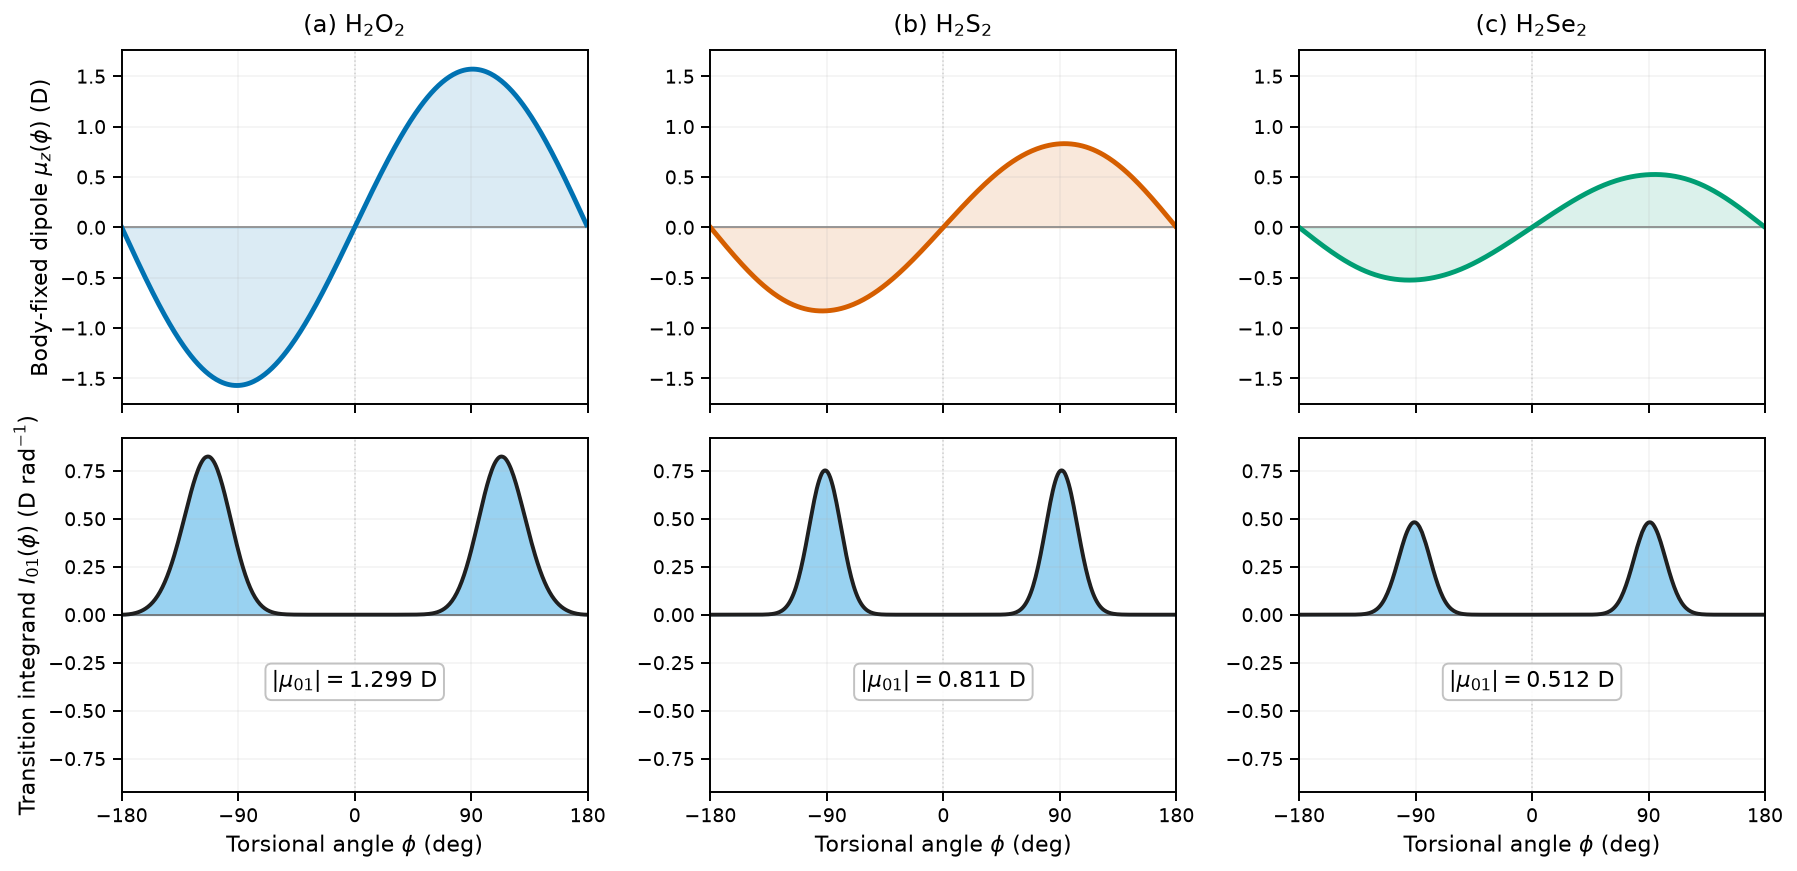

Saved: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figures_maintext/Fig02_dipole_transition_integrand.pdf
Saved: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figures_maintext/Fig02_dipole_transition_integrand.png
Saved: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figure_data_maintext/Fig02_dipole_transition_integrand.csv
Saved: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figure_data_maintext/Fig02_transition_integral_audit.csv


In [4]:
# ============================================================
# 3. Plot Figure 2
# ============================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(13.2, 6.8),
    sharex="col",
)

positive_fill = "#56B4E9"
negative_fill = "#E69F00"

# Common row-wise limits make the chemical trend directly visible.
mu_max = max(np.max(np.abs(data[m]["mu_z_D"])) for m in MOLECULES)
integrand_max = max(np.max(np.abs(data[m]["integrand_D_per_rad"])) for m in MOLECULES)

source_rows = []

for column, molecule in enumerate(MOLECULES):
    row = data[molecule]
    order = np.argsort(row["phi_rad"])

    phi_deg = row["phi_deg"][order]
    phi_rad = row["phi_rad"][order]
    mu = row["mu_z_D"][order]
    integrand = row["integrand_D_per_rad"][order]
    psi_plus = row["psi_plus_phi"][order]
    psi_minus = row["psi_minus_phi"][order]

    ax_mu = axes[0, column]
    ax_int = axes[1, column]
    color = COLORS[molecule]

    # Top: odd dipole function.
    ax_mu.axhline(0.0, color="0.55", lw=0.9)
    ax_mu.axvline(0.0, color="0.82", lw=0.8, ls=":")
    ax_mu.plot(phi_deg, mu, color=color, lw=2.5)
    ax_mu.fill_between(phi_deg, 0.0, mu, color=color, alpha=0.14)
    ax_mu.set_title(f"({chr(97 + column)}) {LABELS[molecule]}", pad=9)
    ax_mu.set_ylim(-1.12 * mu_max, 1.12 * mu_max)
    ax_mu.grid(alpha=0.16)

    # Bottom: physical-dihedral transition integrand.
    ax_int.axhline(0.0, color="0.45", lw=0.9)
    ax_int.axvline(0.0, color="0.82", lw=0.8, ls=":")
    ax_int.plot(phi_deg, integrand, color="0.12", lw=2.0)
    ax_int.fill_between(
        phi_deg, 0.0, integrand,
        where=integrand >= 0,
        interpolate=True,
        color=positive_fill,
        alpha=0.60,
    )
    ax_int.fill_between(
        phi_deg, 0.0, integrand,
        where=integrand < 0,
        interpolate=True,
        color=negative_fill,
        alpha=0.60,
    )
    ax_int.set_ylim(-1.12 * integrand_max, 1.12 * integrand_max)
    ax_int.set_xlim(-180, 180)
    ax_int.set_xticks([-180, -90, 0, 90, 180])
    ax_int.set_xlabel(r"Torsional angle $\phi$ (deg)")
    ax_int.grid(alpha=0.16)

    mu_value = abs(row["mu01_phi_D"])

    # Place the compact numerical result in the unused lower half.
    ax_int.text(
        0.0,
        -0.35,
        rf"$|\mu_{{01}}|={mu_value:.3f}\ \mathrm{{D}}$",
        ha="center",
        va="center",
        fontsize=11.5,
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="0.75",
            alpha=0.95,
        ),
        zorder=10,
    )

    for values in zip(phi_rad, phi_deg, mu, integrand, psi_plus, psi_minus):
        phir, phid, muv, intval, pplus, pminus = values
        source_rows.append([
            molecule,
            phir,
            phid,
            muv,
            float(np.real(pplus)),
            float(np.imag(pplus)),
            float(np.real(pminus)),
            float(np.imag(pminus)),
            intval,
        ])

axes[0, 0].set_ylabel(r"Body-fixed dipole $\mu_z(\phi)$ (D)")
axes[1, 0].set_ylabel(r"Transition integrand $I_{01}(\phi)$ (D rad$^{-1}$)")

for ax in axes.flat:
    ax.tick_params(direction="out", length=4.5, width=1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


fig.tight_layout(rect=[0.015, 0.065, 0.995, 0.995], h_pad=1.25, w_pad=1.6)

pdf_path = FIG_DIR / "Fig02_dipole_transition_integrand.pdf"
png_path = FIG_DIR / "Fig02_dipole_transition_integrand.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", pdf_path)
print("Saved:", png_path)

# Editable source data.
csv_path = FIGDATA_DIR / "Fig02_dipole_transition_integrand.csv"
with csv_path.open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow([
        "molecule",
        "phi_rad",
        "phi_deg",
        "mu_z_D",
        "psi_plus_phi_real_per_sqrt_rad",
        "psi_plus_phi_imag_per_sqrt_rad",
        "psi_minus_phi_real_per_sqrt_rad",
        "psi_minus_phi_imag_per_sqrt_rad",
        "transition_integrand_D_per_rad",
    ])
    writer.writerows(source_rows)

audit_path = FIGDATA_DIR / "Fig02_transition_integral_audit.csv"
audit.to_csv(audit_path)
print("Saved:", csv_path)
print("Saved:", audit_path)